# Hacia una medicina preventiva en hipertensión arterial

La hipertensión arterial es uno de los principales factores de riesgo para las enfermedades cardiovasculares, las cuales, a su vez, son una de las causas principales de morbilidad y mortalidad a nivel mundial[1]. La detección temprana de esta afección representa un gran reto, ya que sus síntomas a menudo pasan desapercibidos y el diagnóstico se realiza con frecuencia en etapas avanzadas. Esta situación resalta la importancia de encontrar soluciones que apoyen en la identificación precoz de la hipertensión.

Este proyecto tiene como objetivo desarrollar modelos predictivos basados en datos que permitan estimar el riesgo de hipertensión en pacientes. La finalidad es doble: por un lado, facilitar la identificación temprana de casos y, por otro, identificar los factores clave que influyen en el desarrollo de la enfermedad. Una herramienta de este tipo sería de gran valor para los profesionales de la salud ya que les permitiría fortalecer las campañas y programas de prevención, así como diseñar estrategias de educación en salud más personalizadas. 

## A. Objetivos.
Aplicar técnicas de clasificación basadas en árboles de decisión y K-vecinos más cercanos para construir modelos predictivos que permitan identificar el riesgo de desarrollar hipertensión.

Identificar los factores más relevantes que influyen en el desarrollo de la hipertensión a partir del análisis de los datos.

## B. Conjunto de datos. 
El conjunto de datos incluye información demográfica, de hábitos de vida y antecedentes médicos de individuos, como edad, índice de masa corporal (BMI), consumo de tabaco, así como la presencia de enfermedad cardíaca. El conjunto de datos original se obtuvo de este 
enlace  y fue modificado para los fines de este proyecto.

## C. Actividades para realizar.
-Exploración y perfilamiento de los datos, utilizando las funcionalidades de la librería pandas. Recuerda que este paso es muy importante para determinar problemas de calidad (por ejemplo, valores ausentes y registros duplicados) y tomar decisiones relacionadas con la preparación de los datos para el algoritmo de aprendizaje. 

-Limpieza y preparación de los datos, justificando las decisiones tomadas con base en los resultados obtenidos en el paso anterior.

-Construcción de un modelo de árboles de decisión. Utiliza la función GridSeacrhCV, con el siguiente espacio de búsqueda: {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10,12],'min_samples_split':[3, 4, 5]}. 

-Construcción de un modelo utilizando el algoritmo K-vecinos más cercanos. Para determinar el número de vecinos utiliza los siguientes valores de K: [1, 2, 3, 4, 5].

-Elaboración de una tabla comparativa mostrando el rendimiento sobre test de los dos modelos seleccionados (con mejores rendimientos) de las actividades 3 y 4, sobre las métricas exactitud, recall, precisión y F-score.

-Utilizando el modelo de árboles de decisión, hasta con una profundidad de tres (3), genera las reglas que permitan determinar cuándo un paciente está en riesgo de sufrir hipertensión (no es necesario volver a construir el árbol).

## D. Consideraciones.
Al hacer la división entrenamiento – test utiliza un valor de semilla de 77 (random_state). 

## E. Análisis de resultados.
Una vez construido los modelos, debes responder estas preguntas:

-¿Qué puedes decir de los valores de las métricas recall y precisión para cada una de las clases en cada modelo? ¿Cuál de estás métricas consideras que es más importante con base en la descripción del problema?

-¿Consideras que el rendimiento de los modelos es adecuado? Si no es así, ¿cómo podrían mejorarse los resultados?

-¿Cuáles son las variables más significativas según el mejor modelo basado en árboles de decisión? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

-Si los dos modelos proporcionan resultados similares en cuanto a las métricas de rendimiento ¿Cuál seleccionarías tomando en cuenta el contexto del problema?


##  G. Criterios de evaluación.

| Actividad | Porcentaje| 
|---|---|
| Se realiza la exploración y perfilamiento de los datos. | 5%  | 
| Se realiza la limpieza y preparación de los datos, justificando las decisiones tomadas.| 10%  | 
| Se construye el modelo de árboles de decisión utilizando una técnica de selección de modelos sobre los valores especificados en la sección C, punto 3.| 15%  | 
| Se construye el modelo utilizando K-vecinos más cercanos utilizando una técnica de selección de modelos sobre los valores especificados en la sección C, punto 4.| 15%  | 
| Se construye la tabla comparativa mostrando el rendimiento sobre test de los dos mejores modelos, sobre las métricas exactitud, recall, precisión y F-score.| 10%  | 
| Se generan las reglas que indican cuándo un paciente está en riesgo de sufrir hipertensión a partir del modelo basado en árboles, con una profundidad de tres (3).| 15%  | 
| Se presenta el análisis de resultados con base en las preguntas de la sección E. | 30%  | 


##  Importación de librerías requeridas

Importo  las librerías `pandas`,`numpy` y `scikit-learn`,  En particular, uso las siguientes clases y funciones para construir,entrenar y evaluar los modelos:

* `ProfileReport` :para poder visualizar, hacer Perfilamiento y calidad de datos 
* `Pipeline()`: clase para construir el pipeline.
* `ColumnTransformer()`: clase para realizar transformaciones por columnas.
* `StandardScaler()`,`MinMaxScaler()`,`RobustScaler()`: clases para realizar la estandarización.
* `OneHotEncoder()`: clase para realizar la codificación OneHot.
* `LabelEncoder()` : clase que transforma mi variable objetivo categórica en valores numéricos (uno por categoría).
* `KNeighborsClassifier()`: clase para crear el modelo de KNN.
* `DecisionTreeClassifier()`: clase para crear el modelo de árbol de decisión.
* `classification_report()`: función para obtener un reporte con las métricas de rendimiento por clase.
* `ConfusionMatrixDisplay()`: clase para graficar la matriz de confusión.
* `accuracy_score()`: función para obtener la exactitud en un modelo de clasificación.
* `precision_score()`: función para obtener la precisión en un modelo de clasificación.
* `recall_score()`: función para obtener la sensibilidad en un modelo de clasificación.
* `f1_score()`: función para obtener la métrica F1 en un modelo de clasificación.
* `GridSearchCV()`: clase para entrenar múltiples modelos variando sus parámetros. Se utiliza para hacer una búsqueda exhaustiva de los mejores valores para el entrenamiento de un modelo.
* `KFold()`: clase para definir múltiples conjuntos de entrenamiento y validación sobre nuestro conjunto de datos.
* `validation_curve()`: función para generar las métricas de desempeño en una curva de validación.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,GridSearchCV, KFold,validation_curve
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder,StandardScaler,RobustScaler,MinMaxScaler,LabelEncoder
from ydata_profiling import ProfileReport
from importlib.metadata import version



In [3]:
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de Numpy: {version('numpy')}")


Versión de Pandas: 2.3.1
Versión de Scikit-learn: 1.7.1
Versión de Numpy: 2.0.0


##  Carga de datos

Realizo la carga de datos usando la función de Pandas `read_csv()`, especificando la ruta:

In [4]:
data_raw = pd.read_csv('./Datos_hipertension.csv')


Reviso los primeros datos del conjunto utilizando `head()`:

In [5]:
data_raw.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duracion_Sueño,BMI,Medicacion,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


## 1. Exploración del conjunto de datos

reviso  las dimensiones del dataset  utilizando `data_raw.shape`:

In [6]:
data_raw.shape

(1990, 13)

Para obtener una vista más detallada de las variables utilizo la libreria YData Profiling generando  un reporte para poder visualizar y revisar mas detalladamente los datos

In [7]:
profile = ProfileReport(data_raw, explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 294734.88it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#### En el análisis del anterior  puedo indigar que existen __registros duplicados(4)__, que no existe correlacion entre los Datos,observo que existen __7 variabes numericas y 6 variables categoricas__  de acuerdo al diccionario de datos la variable  `Ingesta_sal` es categorica y en la exploracion de los datos encuentro que es nùmerica, la variables __colesterol__ presenta Outliers, adicional a esto y con la consulta con los dueños de los datos adjunto las siguientes aclaraciones y las acciones a tomar.

### Variables

#### `Ingesta_Sal`
#### En el diccionario __Ingesta_sal__ está definida como una variable categórica, con tres categorías. Sin embargo, aparece en los datos como numérica.podria realizar una discretización pero no conocemos los intervalos de discretización. __La recomendación que se recibe por parte de los expertos es:`no usarla`__. 


#### `BMI`
#### revisando el valor mínimo es de 11.9 y el máximo de 41.9 y con la ayuda de la grafica Bloxplot puedo identificar que existe valores atipicos . Revisando con los dueños de los datos indican que para el índice de masa corporal se definen, en general, los siguientes rangos: 
*	`Bajo peso` (menos de 18.5)
*	`Normal` (18.5-24.9)
*	`Sobrepeso` (25-29.9)
*	`Obesidad` (30 o más).
#### Valores por debajo de 18 son indicadores de delgadez extrema. __Para el estudio se sugiere no utilizar estos valores__


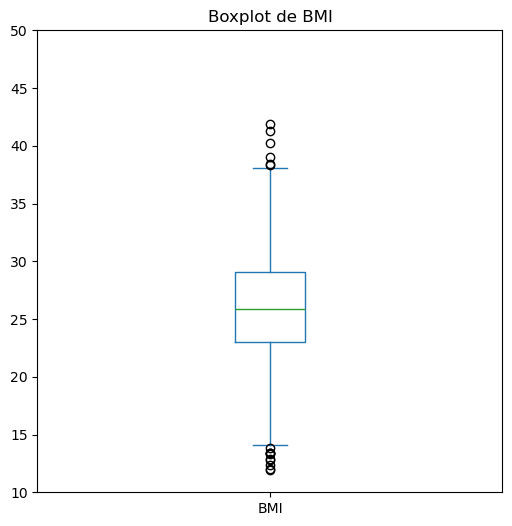

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
data_raw["BMI"].plot(kind="box", title="Boxplot de BMI", figsize=(6,6)) 
plt.ylim(10, 50)
plt.show()


#### `Duración_Sueño`
#### en la exploracion de esta variable observo que los datos deberian ser en horas de acuerdo al diccionario pero se encuentra con valores de deciamales , de acuerdo con la consulta con los dueños de los datos no se tiene claro la forma en como se medio  __La recomendación es:`no usarla`__. 


#### `Colesterol`

#### revisando los datos  y con la ayuda de la grafica Boxplot , observo outliers con valores superiores 1000 mg/dl(1597 mg/dl,2360 mg/dl) , con la ayuda de los expertos en los datos indican que para el colesterol se definen, en general, los siguientes rangos: los rangos a utlizar  en población adulta son:
*	`Normal`: menos de 200 mg/dl
*	`Normal-alto`: entre 200 y 240 mg/dl. Se considera hipercolesterolemia a los niveles de colesterol total superiores a 200 mg/dl.
*	`Alto`: por encima de 240 mg/dl

#### Aunque un valor de `1000` puede presentarse, no se recomienda utilizarlo en este estudio. Valores por encima de este valor se consideran errores, por lo que __la recomendación es no utilizar estos registros__.


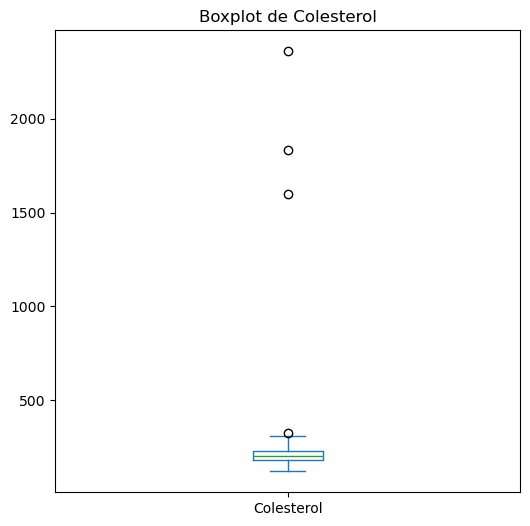

In [9]:
%matplotlib inline
data_raw["Colesterol"].plot(kind="box", title="Boxplot de Colesterol", figsize=(6,6)) 
plt.show()

####  `Glucosa`

#### revisando los datos  y con la ayuda de la grafica Boxplot , observo outliers con valores superiores 165 mg/dL , con la ayuda de los expertos en los datos indican que para la glucosa en sangre  se definen, en general, los siguientes rangos: 
* Menos de 100 mg/dL (5,6 mmol/L) se considera normal.
* Entre 100 y 125 mg/dL (5,6 a 6,9 mmol/L) se diagnostica como prediabetes.
* 126 mg/dL (7,0 mmol/L) o más en dos pruebas distintas se puede diagnosticar como diabetes. 
#### Aunque un valor de `199` se considera muy alto, se presenta en pacientes con diabetes y sería de interés para este estudio. por lo que en este caso no se deberia aplicar ninguna operacion en la limpieza de los datos.


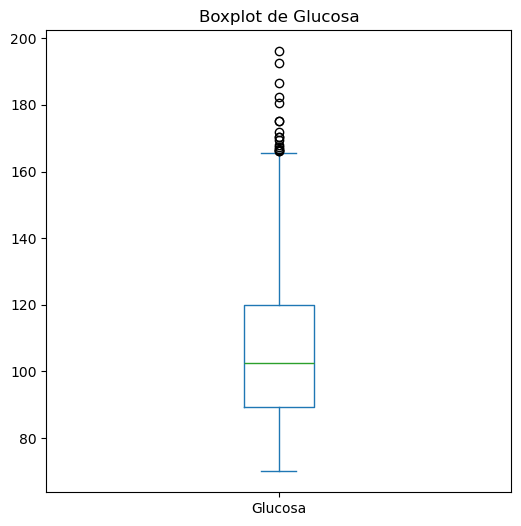

In [10]:
%matplotlib inline
data_raw["Glucosa"].plot(kind="box", title="Boxplot de Glucosa", figsize=(6,6)) 
plt.show()

#### `Datos Duplicados`
#### existen 4 datos duplicados pero no existe un identificador para poder dectectar de si pertenece a una misma persona y de acuerdo con los dueños de los datos estos datos duplicados deben eliminarse.

## 2. Limpieza y preparación de datos

Primero  defino la variable `data` para almacenar el conjunto de datos modificado, utilizando el método `copy()`:

In [11]:
data = data_raw.copy()

#### Eliminación de variables
de acuerdo a la exploracion y las recomendaciones por partes de los expertos de los datos, eliminare la Varibles Ingesta_Sal y Duración_Sueño

In [12]:
data = data.drop(['Ingesta_Sal','Duracion_Sueño'], axis= 1)

In [13]:
data.head()

,Edad,Nivel_Stres,Colesterol,BMI,Medicacion,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,9,242.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,10,177.2,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,3,193.0,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10,268.1,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,1,175.3,16.2,Otro,No,Moderada,No,101.5,No,No


#### `Eliminación de Valores Atipicos`
#### de acuerdo a la exploracion y las recomendaciones por partes de los expertos de los datos, eliminare los valores atipicos presentes en las variables BMI Valores por debajo de 18 son indicadores de delgadez extrema. __Para el estudio se sugiere no utilizar estos valores__ y en la variable colesterol un valor de `1000` puede presentarse, no se recomienda utilizarlo en este estudio. Valores por encima de este valor se consideran errores, por lo que __la recomendación es no utilizar estos registros__. 

###  `Eliminación de Valores Atipicos en Variable BMI`

##### Verifico antes de la eliminacion

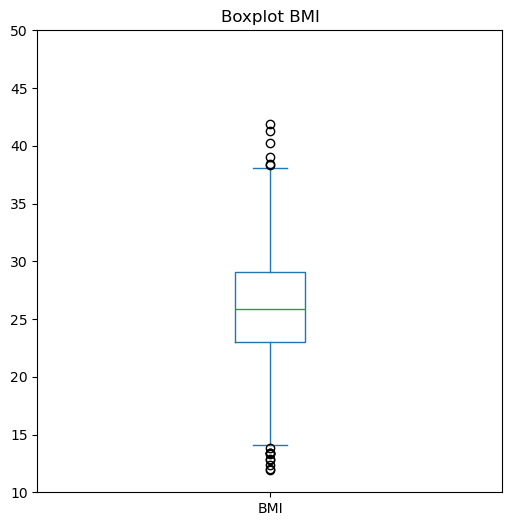

In [14]:
%matplotlib inline
data["BMI"].plot(kind="box", title="Boxplot BMI", figsize=(6,6)) 
plt.ylim(10, 50)
plt.show()

##### con esta sentencia solo selecciono los valores que esten por encima de 18

In [15]:
data = data[data['BMI'] > 18 ]


##### con la ayuda de la grafica de Boxplot verifico los datos

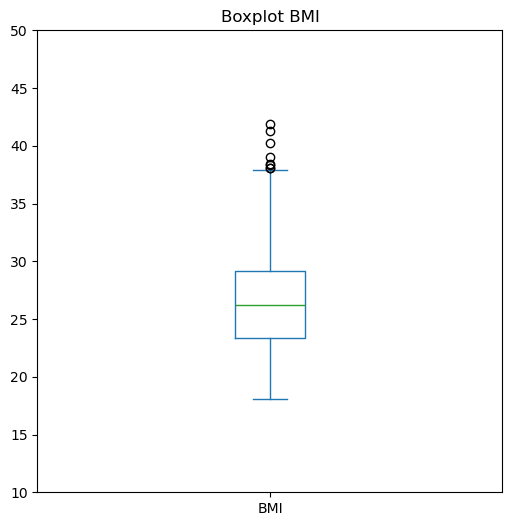

In [16]:
%matplotlib inline
data["BMI"].plot(kind="box", title="Boxplot BMI", figsize=(6,6)) 
plt.ylim(10, 50)
plt.show()

###  `Eliminación de Valores Atipicos en Variable Colesterol`

##### Verifico antes de la eliminacion

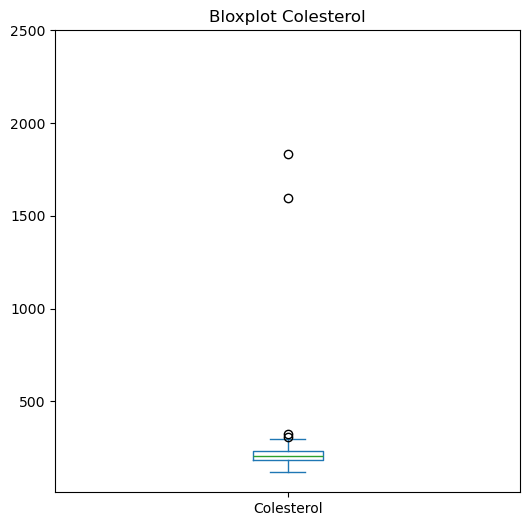

In [17]:
%matplotlib inline
data['Colesterol'].plot(kind="box", title='Bloxplot Colesterol', figsize=(6,6))
plt.ylim(10,2500)
plt.show()

##### con esta sentencia solo selecciono los valores que esten por debajo  de 1000

In [18]:
data = data[data['Colesterol'] < 1000 ]

##### con la ayuda de la grafica de Boxplot verifico los datos

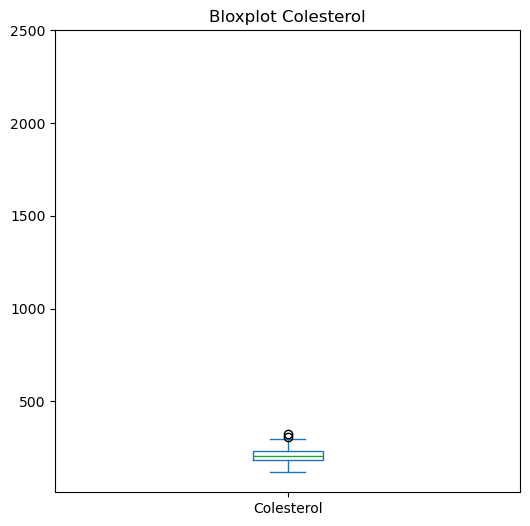

In [19]:
%matplotlib inline
data['Colesterol'].plot(kind="box", title='Bloxplot Colesterol', figsize=(6,6))
plt.ylim(10,2500)
plt.show()

### Eliminación de nulos y duplicados

reviso si el dataset contienen datos nulos usando `isna().sum()`: 

In [20]:
data.isna().sum()

Edad                  0
Nivel_Stres           0
Colesterol            0
BMI                   0
Medicacion            0
Historia_Familiar     0
Actividad_Fisica      0
Fumador               0
Glucosa               0
Enfermedad_Corazon    0
Hipertension          0
dtype: int64

Como no se tienen datos nulos, no tendre que realizar ninguna modificación.Ahora reviso si hay duplicados utilizando `duplicated().sum()`:

In [21]:
data.duplicated().sum()

np.int64(4)

Aqui puedo observar que existen 4 instancias duplicadas en el dataset, de acuerdo a los expertos de los datos los eliminare. Por lo que usare `drop_duplicates()` para eliminarlas. Luego, reviso nuevamente los duplicados y debo obtener un valor de 0

In [22]:
data = data.drop_duplicates()

In [23]:
data.duplicated().sum()

np.int64(0)

##### Después de eliminar las instancias duplicadas y realizar la limpieza del Dataset, continuo con en el entrenamiento del modelo,existen variables categoricas por lo que utilizare el método OneHotEncoder() de la librería `sklearn.preprocessing`  para poder utilizarlas  en el entrenamiento de los modelos de aprendizaje y con la ayuda de la misma libreria ulizare los metodos adecuados para realizar la Estadarizacion de las variables Numéricas.

## 3. Construcción de un modelo de Árbol de decision. 
Para resolver este punto donde debo  crear un modelo de árboles de decisión. Utilizando la función GridSeacrhCV, con el siguiente espacio de búsqueda: {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10,12],'min_samples_split':[3, 4, 5]},  Primero realizare ciertas Transformaciones y Estadarizaciones para poder entrenar el modelo, y despues con la ayude de la Funcion GridSearchCV se estableceran los mejores parametros.


### División de datos



separo la variable Target y las variables independientes para, posteriormente, crear los conjuntos de entrenamiento y pruebas:

In [24]:
X = data.drop(['Hipertension'], axis = "columns")
Y = data["Hipertension"]

Verifico que nuestro conjunto `X` no contiene la variable `Hipertension` usando `X.head()`:

In [25]:
X.head()

,Edad,Nivel_Stres,Colesterol,BMI,Medicacion,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon
0,69,9,242.4,25.8,Ninguna,Si,Baja,No,127.8,Si
1,32,10,177.2,23.4,Ninguna,No,Baja,No,105.9,No
2,78,3,193.0,18.7,Ninguna,No,Moderada,No,102.7,No
3,38,10,268.1,22.1,InhibidorACE,No,Baja,No,99.0,No
5,20,3,224.1,21.9,BloqueadorBeta,Si,Alta,No,135.0,No


In [26]:
Y.head()

0    Si
1    No
2    No
3    Si
5    Si
Name: Hipertension, dtype: object

de acuerdo a las buenas practicas y  para evitar una inoculacion en los datos a utilizar para el rendimiento del modelo  , **El primer paso es separar los datos en entrenamiento y test.**

Ahora, divido el conjunto de datos resultante en un conjunto de entrenamiento y uno de pruebas mediante la función `train_test_split()`. Uso el 80% de los datos para el entrenamiento y el 20% restante para las pruebas, una proporción estándar.

`test_size` nos permite establecer el porcentaje de datos que queremos para pruebas, `0.2` corresponde al 20%

La división de datos es aleatoria, el parámetro `random_state` nos permite reproducir los resultados al ejecutar la división varias veces. para eso y de acuerdo a las consideraciones indicadas en el enunciado del proyecto ( __Consideraciones__: Al hacer la división entrenamiento – test utiliza un `valor de semilla de 77 (random_state).`) utlizare dicho valor.

la función `reset_index(drop=True)` reinicia la numeración de los registros del dataframe, esto es útil para combinar o separar los datos más adelante

In [27]:
x_train, x_test, y_train , y_test = train_test_split(X,Y, test_size= 0.2 , random_state=77)
x_train = x_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
x_test = x_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
x_train.head()

,Edad,Nivel_Stres,Colesterol,BMI,Medicacion,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon
0,53,1,272.6,30.8,Diuretico,Si,Baja,No,129.3,No
1,62,9,207.0,20.9,Diuretico,Si,Moderada,No,127.1,No
2,22,7,211.2,24.7,Ninguna,No,Alta,No,122.8,No
3,55,1,170.7,24.0,Diuretico,No,Moderada,No,111.1,No
4,52,2,193.4,26.3,InhibidorACE,No,Baja,Si,115.0,No


Verifico  las dimensiones del conjunto de datos modificado usando `shape`:

In [28]:
x_train.shape, y_train.shape

((1528, 10), (1528,))

In [29]:
x_test.shape, y_test.shape

((383, 10), (383,))

### Variable Objetivo

como mi variable objetivo es categorica y la implementacion de `scikit-learn` necesita que todos los valores de las variables sean numéricas usare la clase  `LabelEncoder()` adiconal mas adelante me ayudara para el calculo de las metricas de rendimiento de mi modelo.


In [30]:
label = LabelEncoder()
y_train_enc = label.fit_transform(y_train)
y_test_enc = label.transform(y_test)

In [31]:
print(y_train_enc)

[1 1 1 ... 0 1 0]


Haciendo uso de Pipelines, realizare ciertas transformaciones sobre el conjunto de train y despues realizare busqueda del modelo que mejor generalize los datos.

### Transformación de variables categóricas

Teóricamente, el modelo de árboles de decisión no necesita que todas las variables sean numéricas, pues simplemente genera divisiones según un criterio a optimizar, usando la distribución de los valores para cada variable. Sin embargo, la implementación de scikit-learn sí necesita que todos los valores de las variables sean numéricos, por lo que usaremos la clase OneHotEncoder(),incluire  una codificación OneHot dentro del pipeline mediante un objeto de la clase OneHotEncoder(), especificando que la salida no necesita manejo especial por dispersión con sparse_output=False:


In [32]:
encoder = OneHotEncoder(sparse_output=False)

Utilizo la clase `ColumnTransformer()` que recibe una lista de tuplas (nombre, objeto, columnas) especificando qué objeto se usará con qué conjunto de variables. esto es util para especificar las columnas que  serán procesadas por el paso de codificación  y evitar afectar variables que no corresponder.

__Nota:__ por defecto, la clase `ColumnTransformer()` va a agregar el nombre del paso ejecutado a cada variable, para evitar esta accion uso el parametro verbose_feature_names_out=False

In [33]:
numeric_features = ['Edad', 'Nivel_Stres','BMI','Colesterol','Glucosa']
categorical_features = ['Medicacion','Historia_Familiar','Actividad_Fisica','Fumador','Enfermedad_Corazon']
column_transformer_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", encoder, categorical_features)
    ],
    verbose_feature_names_out=False
)


en el anterior paso detalle dos listas con los índices de las variables numéricas y categóricas (numeric_features y categorical_features) que utilizare  para especificar el parámetro transformers.El objeto column_transformer es el que incluire en mi pipeline.

#### El modelo de árboles de decisión no necesita estandarizar las variables para realizar las particiones. por lo que no incluyo este paso en las transformaciones de las columnas

### Creacion Pipeline

Lo primero que haré es definir el objeto de la clase `DecisionTreeClassifier()` de `scikit-learn` que será el modelo base para realizar la búsqueda exhaustiva de hiperparámetros.

In [34]:
decision_tree = DecisionTreeClassifier(random_state=77)

La librería scikit-learn utiliza el concepto de transformadores y estimadores para la implementación de todas sus clases. Un transformador es un objeto que implementa los métodos fit() y transform(), que procesan un conjunto de datos de entrada y aplican operaciones sobre ellos. Por otro lado, un estimador es un objeto que implementa el método fit() y genera modelos a partir de datos. En ese sentido, un pipeline es una estructura que aplica transformadores secuecialmente y termina con un estimador sobre un conjunto de datos.

Para nuestro problema definire la secuencia de pasos que aplicaré sobre el conjunto de datos, utilizando tuplas de la forma (nombre, objeto):

In [35]:
steps = [
    ("transformer",column_transformer_tree),
     ("model", decision_tree),
]



Con la secuencia de pasos definida, creo un objeto de la clase Pipeline() para realizar el preprocesamiento junto con la función .set_output(transform='pandas') para mantener los datos como DataFrame luego del preprocesamiento:

In [36]:
pipeline = Pipeline(steps).set_output(transform='pandas')
pipeline

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### Búsqueda de hiperparámetros para el modelo de árbol de decisión

deseo  encontrar un valor que resulte en el mejor desempeño posible. voy automatizar el proceso de búsqueda de hiperparámetros mediante la clase `GridSearchCV`, que entrena múltiples modelos y retorna el que tiene mejor desempeño.



Aprovecho uno de los beneficios de los pipelines de poder incluir otros parámetros diferentes a los del modelo dentro de la búsqueda de hiperparámetros. En ese sentido, utilizo los siguientes parámetros para realizar la búsqueda: {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10,12],'min_samples_split':[3, 4, 5]}

* criterion: el criterio de pureza, que determina la calidad de una división. Utilizaremos dos de los más populares: la entropía y GINI.
* max_depth: la profundidad máxima del árbol. Este hiperparámetro se utiliza para el control de la complejidad del modelo.
* min_samples_split: número mínimo de datos necesarios en un nodo para poder definir una división.

Para especificar qué parámetro voy a modificar en cada paso, utilizo la estructura <paso>__<parámetro> para definir las llaves del diccionario. En el caso de los ColumnTransformer(), que usan varios objetos en paralelo, utilizaremos la estructura <transformer>__<objeto>__<parámetro>,Almaceno estos valores en la variable `param_grid`.

In [37]:
param_grid = {
              'model__criterion': ['entropy', 'gini'],
              'model__max_depth': [4,6,8,10,12],
              'model__min_samples_split': [3, 4,5]
              }

Ahora defino un objeto de la clase `KFold()`, que nos será útil para obtener una estimación del desempeño del modelo . La validación cruzada k-fold es un método que toma el conjunto de entrenamiento original y lo separa en k grupos, usando uno como validación y el resto (k-1) como entrenamiento. Después de definir los grupos, entrena el modelo con el conjunto de entrenamiento y lo evalúa con el conjunto de validación, repitiendo este proceso para cada uno de los k grupos. En este caso, defino `k=10` y uso el parámetro `shuffle=True` para indicar que se cambie el orden de los datos antes de separarlos en los grupos:

In [38]:
kfold = KFold(n_splits=10, shuffle=True, random_state=77)

A continuación,  utilizo `GridSearchCV` para realizar una búsqueda exhaustiva de hiperparámetros. Defino el modelo `decision_tree`, los valores del hiperparámetro `param_grid` y la estrategia de validación cruzada `kfold`. uso el parámetro `n_jobs` para intentar mejorar el rendimiento. 

In [39]:
modelos_grid = GridSearchCV(pipeline,param_grid,cv=kfold, n_jobs=-1)

Finalmente,	Ejecuto la búsqueda sobre el conjunto de entrenamiento original, que será modificado por el pipeline dependiendo de los pasos definidos para cada iteración.

In [40]:
%%time
modelos_grid.fit(x_train, y_train_enc)

CPU times: user 211 ms, sys: 77.1 ms, total: 288 ms
Wall time: 3.05 s


,estimator,Pipeline(step...m_state=77))])
,param_grid,"{'model__criterion': ['entropy', 'gini'], 'model__max_depth': [4, 6, ...], 'model__min_samples_split': [3, 4, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


obtengo el mejor valor del hiperparámetro usando el atributo `best_params_`:

In [41]:
print("Mejor grado:", modelos_grid.best_params_)

Mejor grado: {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_split': 3}


puedo observar que en términos de preprocesamiento se uutiliza la entropía como criterio de pureza, una profundidad máxima de 4 y un mínimo de 3 datos para realizar una división. Almaceno el mejor pipeline completo utilizando `modelos_grid.best_estimator_`:

In [42]:
mejor_pipeline = modelos_grid.best_estimator_
mejor_pipeline

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


utilizo  el atributo feature_importances_ para obtener un arreglo con los pesos asignados a cada variable. Entre más grande sea el peso, más importante es la variable asociada:
Utilizando los nombres de las variables almacenados en x_train.columns, podemos ver más claramente qué peso corresponde a qué variable. Primero creo un DataFrame con los valores almacenados en la variable importancia y, posteriormente, lo ordeno:


In [43]:
rf_model = mejor_pipeline.named_steps["model"]
feature_names = mejor_pipeline.named_steps["transformer"].get_feature_names_out()
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
importances

Colesterol                   0.806605
Glucosa                      0.140143
Enfermedad_Corazon_Si        0.015825
BMI                          0.013791
Historia_Familiar_Si         0.012180
Actividad_Fisica_Baja        0.006834
Fumador_Si                   0.004621
Enfermedad_Corazon_No        0.000000
Fumador_No                   0.000000
Actividad_Fisica_Moderada    0.000000
Actividad_Fisica_Alta        0.000000
Edad                         0.000000
Historia_Familiar_No         0.000000
Nivel_Stres                  0.000000
Medicacion_Ninguna           0.000000
Medicacion_InhibidorACE      0.000000
Medicacion_Diuretico         0.000000
Medicacion_BloqueadorBeta    0.000000
Medicacion_Otro              0.000000
dtype: float64

la variable más importante es Colesterol. las variables como Glucosa, Enfermedad Corazon,BMI,Historia_Familiar_Si,Actividad_Fisica_Baja,Fumador_Si tambien tiene peso en la generalizacion, la demas variables no son importantes.

Ahora utilizo  plot_tree para visualizar el árbol que almacenamos en la variable `rf_model`. Especificaremos el nombre de las variables con el parámetro feature_names, el nombre de las clases (en orden ascendente, es decir, primero la clase 0 y luego la clase 1) con el parámetro class_names y, finalmente, aplicaremos colores a los nodos para indicar cada clase con el parámetro filled:

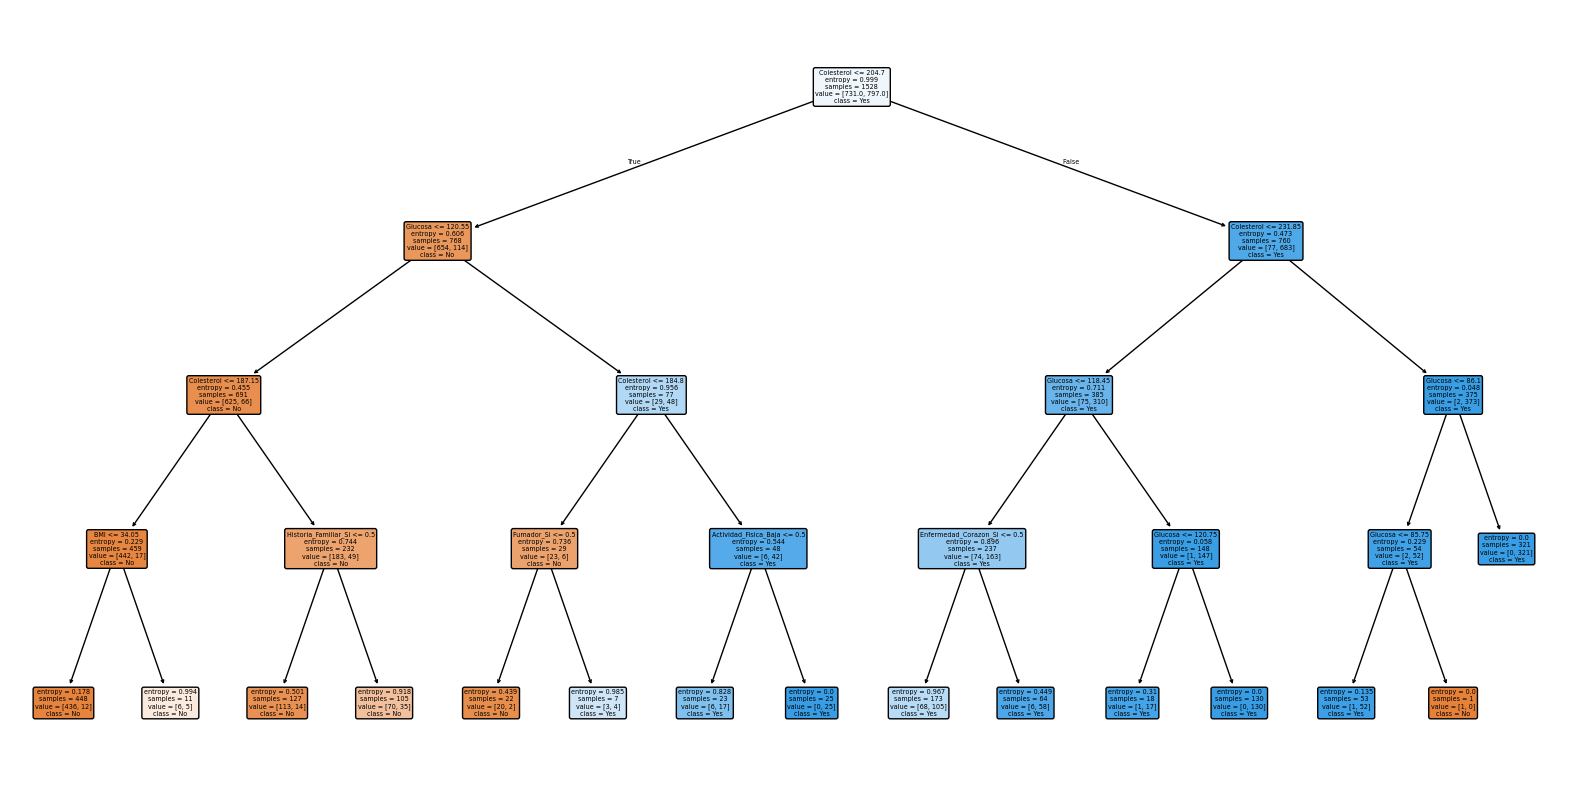

In [44]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    rf_model,
    feature_names=feature_names,
    class_names=["No", "Yes"], 
    filled=True,
    rounded=True
)
plt.show()

obtengo ciertas metricas del funcionamiento del modelo en etapa de Train para mas adelante obtener metricas y poder revisar el funciomamineto del modelo, como observar que no exista sobreajuste o bajoajuste

In [45]:
x_train_transformed = mejor_pipeline[:1].transform(x_train)
x_train_transformed.head(3)

,Edad,Nivel_Stres,BMI,Colesterol,Glucosa,Medicacion_BloqueadorBeta,Medicacion_Diuretico,Medicacion_InhibidorACE,Medicacion_Ninguna,Medicacion_Otro,Historia_Familiar_No,Historia_Familiar_Si,Actividad_Fisica_Alta,Actividad_Fisica_Baja,Actividad_Fisica_Moderada,Fumador_No,Fumador_Si,Enfermedad_Corazon_No,Enfermedad_Corazon_Si
0,53,1,30.8,272.6,129.3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,62,9,20.9,207.0,127.1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,22,7,24.7,211.2,122.8,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [46]:
y_train_pred = mejor_pipeline[1].predict(x_train_transformed)
y_train_pred

array([1, 1, 1, ..., 0, 1, 0])

### Evaluación del mejor modelo

Con la información disponible del conjunto de entrenamiento y con los pasos de preprocesamiento integrados a nuestro modelo, realizo predicciones sobre el conjunto de pruebas directamente mediante la función predict():

In [47]:
y_test_pred = mejor_pipeline.predict(x_test)

In [48]:
y_test_pred

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,

Ahora utilizo la función plot_confusion_matrix() para generar un mapa de calor con los valores de la matriz de confusión, ajusto el parametro labels = [1, 0 ] para poder poder visualizar la matriz de confusion de la siguiente forma 
|  VP   | FN | 
|---|---|
|  FP   | VN | 

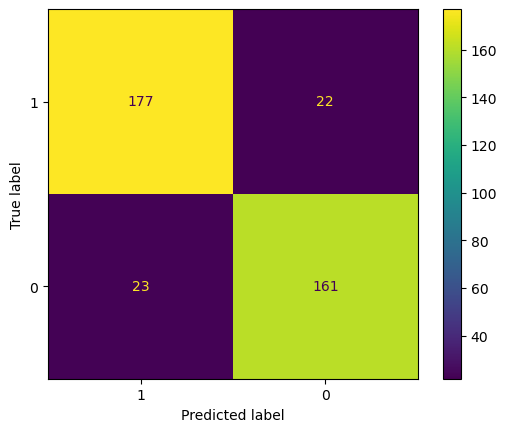

In [49]:
ConfusionMatrixDisplay.from_estimator(mejor_pipeline,x_test,y_test_enc,labels=[1, 0])
plt.show()

In [50]:
confusion_matrix(y_test_enc,y_test_pred,labels=[1, 0])

array([[177,  22],
       [ 23, 161]])

Aqui puedo observar que  el modelo tiende a predecir correctamente la clase 1, es decir, tiene mejor desempeño al predecir a las personas que sufren de hipertension. Específicamente,observo las métricas de desempeño usando classification_report():


In [51]:
print(classification_report(y_test_enc,y_test_pred,labels=[1, 0] ))

              precision    recall  f1-score   support

           1       0.89      0.89      0.89       199
           0       0.88      0.88      0.88       184

    accuracy                           0.88       383
   macro avg       0.88      0.88      0.88       383
weighted avg       0.88      0.88      0.88       383



In [52]:
error = 1 - accuracy_score(y_test_enc, y_test_pred)
print("Error de clasificación:", error)

Error de clasificación: 0.11749347258485643


De los 199 casos reales de clase 1 (hipertensión), el modelo predijo correctamente 177 y falló en 22 → recall = 0.89.
De los 184 casos reales de clase 0 (no hipertensión), predijo correctamente 161 y falló en 23 → recall = 0.88.

#### El modelo presenta valores altos de precisión y sensibilidad tanto en la clase 1 (hipertensión) como en la clase 0 (no hipertensión), con métricas alrededor de 0.88–0.89. Esto significa que:

* Cuando el modelo predice que una persona tiene hipertensión (clase 1), en la mayoría de los casos es correcto (alta precisión). Además, logra identificar correctamente a casi todas las personas con hipertensión reales (alto recall).
* El buen equilibrio entre precisión y recall se refleja también en un F1-score alto (≈0.89).
En conclusión, el modelo distingue correctamente entre personas con y sin hipertensión, mostrando un desempeño sólido y balanceado,Así que el modelo no está sesgado hacia una clase, sino que se comporta equilibradamente


#### Revisión de sobreajuste
Cuando entrenamos modelos de aprendizaje, el conjunto de datos de prueba nos permite saber qué tan bien se desempeña el modelo con datos que no conoce. Sin embargo, hay que tener cuidado con 2 situaciones perjudiciales que llamaremos bajoajuste o underfitting, y sobreajuste o overfitting.

A grandes rasgos, consideramos que un modelo está bajoajustado si su rendimiento en general es bajo; y un modelo como sobreajustado si su capacidad de generalización (es decir, funcionar con datos que no conoce) es mala.

Para saber si un modelo presenta alguno de estos casos, lo que debemos hacer es comparar el rendimiento del modelo con datos tanto conocidos como nuevos, esto lo podemos lograr revisando qué tanto cambian las métricas del modelo si predecimos sobre los datos de entrenamiento y los de test:

Anteriormente ya calcule predicciones con los datos tanto de entrenamiento como de test, por lo que haremos la comparación de métricas directamente en una tabla:

In [53]:
accuracy_train = accuracy_score(y_train_enc,y_train_pred)
recall_train = recall_score(y_train_enc,y_train_pred)
precision_train = precision_score(y_train_enc,y_train_pred)
f1_score_train = f1_score(y_train_enc,y_train_pred)

accuracy_test = accuracy_score(y_test_enc,y_test_pred)
recall_test = recall_score(y_test_enc,y_test_pred)
precision_test = precision_score(y_test_enc,y_test_pred)
f1_score_test = f1_score(y_test_enc,y_test_pred)

tabla=f"""
|  Métrica   | Train | Test |
|------------|-------|------|
|Exactitud   |{accuracy_train:.2%} |{accuracy_test:.2%}|
|Sensibilidad|{recall_train:.2%} |{recall_test:.2%}|
|Precisión   |{precision_train:.2%} |{precision_test:.2%}|
|F1-Score    |{f1_score_train:.2%} |{f1_score_test:.2%}|"""
print(tabla)


|  Métrica   | Train | Test |
|------------|-------|------|
|Exactitud   |89.99% |88.25%|
|Sensibilidad|91.47% |88.94%|
|Precisión   |89.56% |88.50%|
|F1-Score    |90.50% |88.72%|


En este caso, los valores de cada métrica son cercanos en ambos conjuntos de datos, por lo que podemos concluir que el modelo actual no presenta signos de bajoajuste ni sobreajuste.

## 4. Construcción de un modelo de K-vecinos más cercanos. 

Para determinar el número de vecinos utilizo los siguientes valores de K: [1, 2, 3, 4, 5]

### División de datos

separo la variable Target y las variables independientes para, posteriormente, crear los conjuntos de entrenamiento y pruebas:

In [54]:
X_K = data.drop(['Hipertension'], axis = "columns")
Y_K = data["Hipertension"]


Verifico que nuestro conjunto `X` no contiene la variable `'Hipertension'` usando `X_K.head()`:

In [55]:
X_K.head()

,Edad,Nivel_Stres,Colesterol,BMI,Medicacion,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon
0,69,9,242.4,25.8,Ninguna,Si,Baja,No,127.8,Si
1,32,10,177.2,23.4,Ninguna,No,Baja,No,105.9,No
2,78,3,193.0,18.7,Ninguna,No,Moderada,No,102.7,No
3,38,10,268.1,22.1,InhibidorACE,No,Baja,No,99.0,No
5,20,3,224.1,21.9,BloqueadorBeta,Si,Alta,No,135.0,No


de acuerdo a las buenas practicas y  para evitar una inoculacion en los datos a utilizar para el rendimiento del modelo  , **El primer paso es separar los datos en entrenamiento y test.**

Ahora, divido el conjunto de datos resultante en un conjunto de entrenamiento y uno de pruebas mediante la función `train_test_split()`. Uso el 80% de los datos para el entrenamiento y el 20% restante para las pruebas, una proporción estándar.

`test_size` nos permite establecer el porcentaje de datos que queremos para pruebas, `0.2` corresponde al 20%

La división de datos es aleatoria, el parámetro `random_state` nos permite reproducir los resultados al ejecutar la división varias veces. para eso y de acuerdo a las consideraciones indicadas en el enunciado del proyecto ( __Consideraciones__: Al hacer la división entrenamiento – test utiliza un `valor de semilla de 77 (random_state).`) utlizare dicho valor.

la función `reset_index(drop=True)` reinicia la numeración de los registros del dataframe, esto es útil para combinar o separar los datos más adelante


In [56]:
x_train_K, x_test_K, y_train_K , y_test_K = train_test_split(X_K,Y_K, test_size= 0.2 , random_state=77)
x_train_K = x_train_K.reset_index(drop=True)
y_train_K = y_train_K.reset_index(drop=True)
x_test_K = x_test_K.reset_index(drop=True)
y_test_K = y_test_K.reset_index(drop=True)
x_train_K.head()


,Edad,Nivel_Stres,Colesterol,BMI,Medicacion,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon
0,53,1,272.6,30.8,Diuretico,Si,Baja,No,129.3,No
1,62,9,207.0,20.9,Diuretico,Si,Moderada,No,127.1,No
2,22,7,211.2,24.7,Ninguna,No,Alta,No,122.8,No
3,55,1,170.7,24.0,Diuretico,No,Moderada,No,111.1,No
4,52,2,193.4,26.3,InhibidorACE,No,Baja,Si,115.0,No


Verifico  las dimensiones del conjunto de datos modificado usando `shape`:

In [57]:
x_train_K.shape, y_train_K.shape

((1528, 10), (1528,))

In [58]:
x_test_K.shape, y_test_K.shape

((383, 10), (383,))

### Variable Objetivo

como mi variable objetivo es categorica y la implementacion de `scikit-learn` necesita que todos los valores de las variables sean numéricas usare la clase  `LabelEncoder()` adiconal mas adelante me ayudara para el calculo de las metricas de rendimiento de mi modelo.


In [59]:
label_K = LabelEncoder()
y_train_enc_K = label_K.fit_transform(y_train_K)
y_test_enc_K = label_K.transform(y_test_K)



In [60]:
y_train_enc_K

array([1, 1, 1, ..., 0, 1, 0])

In [61]:
y_test_enc_K

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,

### Transformación de variables categóricas

Debido a que KNN calcula distancias entre un punto particular y los puntos a su alrededor, es necesario tratar nuestras variables categóricas para que sea posible incluirlas en el entrenamiento como variables numéricas. 

### Estandarización

KNN calcula distancias entre puntos, por lo que realizo una estandarización para que la escala de una variable no tenga influencia sobre la clasificación. 


Utilizo la clase `ColumnTransformer()` que recibe una lista de tuplas (nombre, objeto, columnas) especificando qué objeto se usará con qué conjunto de variables. esto es util para especificar las columnas que  serán procesadas por el paso de codificación y por el paso de estandarización y evitar afectar variables que no corresponder.

__Nota:__ por defecto, la clase `ColumnTransformer()` va a agregar el nombre del paso ejecutado a cada variable, para evitar esta accion uso el parametro verbose_feature_names_out=False



In [62]:
encoder_k = OneHotEncoder(sparse_output=False)

In [63]:
scaler = StandardScaler()

In [64]:
numeric_features = ['Edad', 'Nivel_Stres','BMI','Colesterol','Glucosa']
categorical_features = ['Medicacion','Historia_Familiar','Actividad_Fisica','Fumador','Enfermedad_Corazon']
column_transformer_knn = ColumnTransformer(
    transformers=[
        ("num", scaler, numeric_features),
        ("cat", encoder_k, categorical_features)
    ],
    verbose_feature_names_out=False
)


In [65]:
X_train_k_transformed = column_transformer_knn.fit_transform(x_train_K)

In [66]:
feature_names = column_transformer_knn.get_feature_names_out()
X_train_k_transformed = pd.DataFrame(X_train_k_transformed, columns=feature_names, index=x_train_K.index)
X_train_k_transformed

,Edad,Nivel_Stres,BMI,Colesterol,Glucosa,Medicacion_BloqueadorBeta,Medicacion_Diuretico,Medicacion_InhibidorACE,Medicacion_Ninguna,Medicacion_Otro,Historia_Familiar_No,Historia_Familiar_Si,Actividad_Fisica_Alta,Actividad_Fisica_Baja,Actividad_Fisica_Moderada,Fumador_No,Fumador_Si,Enfermedad_Corazon_No,Enfermedad_Corazon_Si
0,0.140852,-1.259396,1.050102,1.966909,1.018511,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,0.603031,1.275154,-1.340289,0.012039,0.922723,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
2,-1.451099,0.641516,-0.422765,0.137198,0.735502,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.243558,-1.259396,-0.591782,-1.069695,0.226087,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
4,0.089499,-0.942577,-0.036439,-0.393239,0.395892,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523,-0.680800,-0.308940,-0.495201,0.226598,-0.422655,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1524,1.578743,0.324698,-0.036439,2.011609,1.366828,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1525,-1.194333,1.275154,-0.108875,-1.495833,-0.252850,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1526,1.424683,0.958335,-1.774905,-0.536278,1.162192,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


### Graficación de una curva de validación para el hiperparámetro K

Para este modelo intentaremos buscar el mejor valor de _k_, representado por el parámetro `n_neighbors` de `KNeighborsClassifier`, mediante una curva de validación. En ese sentido, primero almaceno  en la variable `k_values` los posibles valores de acuerdo a los criterios del proyecto.



In [67]:
k_values = [1, 2, 3, 4, 5]

Al ser un único hiperparámetro, vamos a utilizar la función `validation_curve()` para realizar una curva de validación con el parámetro _k_. Utilizo el conjunto de entrenamiento representado con las variables `x_train_k` y `y_train_k`, modificando el parámetro `n_neighbors` del modelo `KNeighborsClassifier`. Adicionalmente, utilizo una validación cruzada de 10 subconjuntos, almacenando los valores de exactitud en las variables `train_scores` y `val_scores`:

In [68]:
train_scores, val_scores = validation_curve(estimator=KNeighborsClassifier(),
                                            X=X_train_k_transformed,
                                            y=y_train_enc_K,
                                            param_name='n_neighbors',
                                            param_range=k_values,
                                            scoring='accuracy',
                                            cv=10)  

Para graficar estos valores, se obtiene la media y desviación estándar para los conjuntos de entrenamiento y validación generados en la validación cruzada: 

In [69]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

In [70]:
print(train_mean)

[1.         0.90139641 0.93790005 0.90685005 0.92124804]


Finalmente, se visualiza la curva de validación utilizando `matplotlib`:

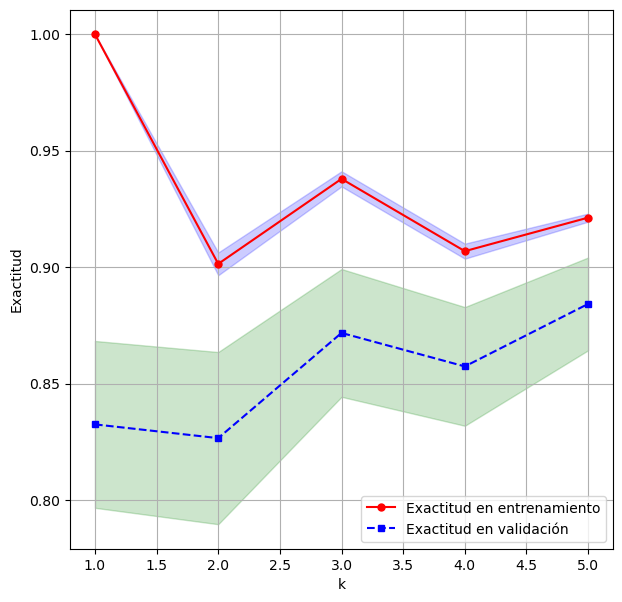

In [71]:
# figura
plt.figure(figsize=(7,7))

# la curva de validación para el conjunto de entrenamiento
plt.plot(k_values, train_mean, color='red', marker='o', markersize=5, label='Exactitud en entrenamiento')
plt.fill_between(k_values, train_mean+train_std, train_mean-train_std, alpha=0.20, color='blue')

# la curva de validación para el conjunto de validación
plt.plot(k_values, val_mean, color='blue', linestyle='--', marker='s', markersize=5, label='Exactitud en validación')
plt.fill_between(k_values, val_mean+val_std, val_mean-val_std, alpha=0.20, color='green')

# grilla y etiquetas para los ejes
plt.grid()
plt.legend(loc='lower right')
plt.xlabel('k')
plt.ylabel('Exactitud')
plt.show()

Un criterio de selección del mejor valor de _k_ es el valor de exactitud más alto en el conjunto de validación. Utilizando `np.argmax()`, podemos obtener el índice de `val_mean` en el que se encuentra el valor más alto:

In [72]:
mejor_indice = np.argmax(val_mean)
mejor_indice

np.int64(4)

Como el valor obtenido es un índice, podemos obtener el valor de _k_ obteniendo el elemento correspondiente de la lista `k_values`:

In [73]:
mejor_k = k_values[mejor_indice]
mejor_k

5

aqui  puedo observar que  el mejor modelo tiene un valor de `n_neighbors=5`. para validar esto ,realizo una búsqueda utilizando `GridSearchCV` para verificar si se obtiene el mismo valor de _k_.

In [74]:
knn = KNeighborsClassifier()

pipeline_knn = Pipeline([
    ("transformer", column_transformer_knn),  
    ("model", knn)
]).set_output(transform="pandas")

param_grid_knn = {
    "transformer__num": [StandardScaler(), MinMaxScaler(),RobustScaler()],
    "model__n_neighbors": [1, 2, 3, 4, 5],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(x_train_K,y_train_enc_K)
print("Mejores parámetros KNN:", grid_knn.best_params_)

Mejores parámetros KNN: {'model__metric': 'euclidean', 'model__n_neighbors': 5, 'model__weights': 'uniform', 'transformer__num': StandardScaler()}


aqui observo que efectivamente los parametros son los mismo de los que habia encontrado anteriormente.
* `model__metric': 'euclidean'`
* `model__n_neighbors': 5 `
* `model__weights': uniform'`
* `transformer__num': StandardScaler()`

En KNN se verifica la clase a la que pertenecen los _k_ datos más cercanos (usando, por defecto, la distancia euclidiana) a un dato que queremos clasificar. Para realizar la clasificación, se realiza una votación entre los _k_ datos, retornando la clase mayoritaria entre ellos. Para este problema, veremos los 5 datos más cercanos para predecir si una persona es Hipertensa o no.

 Creo el mejor modelo utilizando el pipeline, almacenando el resultado en la variable `mejor_pipeline_k` y lo utilizo para calcular metricas para evaluación del modelo mas adelante

In [75]:
mejor_pipeline_k = grid_knn.best_estimator_
mejor_pipeline_k


,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


obtengo ciertas metricas del funcionamiento del modelo en etapa de Train para mas adelante obtener metricas y poder revisar el funciomamineto del modelo, como observar que no exista sobreajuste o bajoajuste

In [76]:
y_train_pred_K = mejor_pipeline_k.predict(x_train_K)
y_train_pred_K


array([1, 1, 0, ..., 0, 1, 0])

###  Evaluación del mejor modelo
Con la información disponible del conjunto de entrenamiento y con los pasos de preprocesamiento integrados a nuestro modelo, realizo predicciones sobre el conjunto de pruebas directamente mediante la función predict():

In [77]:
y_test_pred_K = mejor_pipeline_k.predict(x_test_K)

Ahora utilizo la función plot_confusion_matrix() para generar un mapa de calor con los valores de la matriz de confusión, ajusto el parametro labels = [1, 0 ] para poder poder visualizar la matriz de confusion de la siguiente forma 
|  VP   | FN | 
|---|---|
|  FP   | VN | 

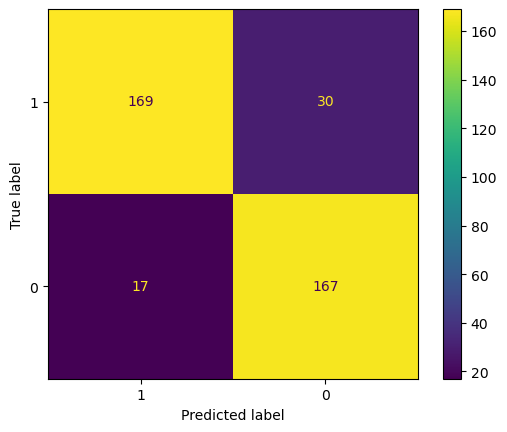

In [78]:
ConfusionMatrixDisplay.from_estimator(mejor_pipeline_k,x_test_K,y_test_enc_K,labels=[1, 0])
plt.show()


In [79]:
confusion_matrix(y_test_enc_K,y_test_pred_K,labels=[1, 0])

array([[169,  30],
       [ 17, 167]])

Aqui puedo observar que  el modelo tiende a predecir correctamente la clase 1, es decir, tiene mejor desempeño al predecir a las personas que sufren de hipertension. Específicamente,observo las métricas de desempeño usando classification_report():

In [80]:
print(classification_report(y_test_enc_K,y_test_pred_K,labels=[1, 0] ))

              precision    recall  f1-score   support

           1       0.91      0.85      0.88       199
           0       0.85      0.91      0.88       184

    accuracy                           0.88       383
   macro avg       0.88      0.88      0.88       383
weighted avg       0.88      0.88      0.88       383



In [81]:
error = 1 - accuracy_score(y_test_enc_K, y_test_pred_K)
print("Error de clasificación:", error)


Error de clasificación: 0.12271540469973885


De los 199 casos reales de clase 1 (hipertensión), el modelo predijo correctamente 169 y falló en 30 → recall = 0.85.
De los 184 casos reales de clase 0 (no hipertensión), predijo correctamente 167 y falló en 17 → recall = 0.91.

#### El modelo presenta valores altos de precisión y sensibilidad tanto en la clase 1 (hipertensión) como en la clase 0 (no hipertensión), con métricas alrededor de 0.85–0.91. Esto significa que:

* Cuando el modelo predice que una persona tiene hipertensión (clase 1), en la mayoría de los casos es correcto (alta precisión). Además, logra identificar correctamente a casi todas las personas con hipertensión reales (alto recall).
* El buen equilibrio entre precisión y recall se refleja también en un F1-score alto (≈0.88).
En conclusión, el modelo distingue correctamente entre personas con y sin hipertensión, mostrando un desempeño sólido y balanceado,Así que el modelo no está sesgado hacia una clase, sino que se comporta equilibradamente


#### Revisión de sobreajuste
Cuando entrenamos modelos de aprendizaje, el conjunto de datos de prueba nos permite saber qué tan bien se desempeña el modelo con datos que no conoce. Sin embargo, hay que tener cuidado con 2 situaciones perjudiciales que llamaremos bajoajuste o underfitting, y sobreajuste o overfitting.

A grandes rasgos, consideramos que un modelo está bajoajustado si su rendimiento en general es bajo; y un modelo como sobreajustado si su capacidad de generalización (es decir, funcionar con datos que no conoce) es mala.

Para saber si un modelo presenta alguno de estos casos, lo que debemos hacer es comparar el rendimiento del modelo con datos tanto conocidos como nuevos, esto lo podemos lograr revisando qué tanto cambian las métricas del modelo si predecimos sobre los datos de entrenamiento y los de test:

Anteriormente ya calcule predicciones con los datos tanto de entrenamiento como de test, por lo que hare la comparación de métricas directamente en una tabla:


In [82]:
accuracy_train_k = accuracy_score(y_train_enc_K,y_train_pred_K)
recall_train_k = recall_score(y_train_enc_K,y_train_pred_K)
precision_train_k = precision_score(y_train_enc_K,y_train_pred_K)
f1_score_train_k = f1_score(y_train_enc_K,y_train_pred_K)

accuracy_test_k = accuracy_score(y_test_enc_K,y_test_pred_K)
recall_test_k = recall_score(y_test_enc_K,y_test_pred_K)
precision_test_k = precision_score(y_test_enc_K,y_test_pred_K)
f1_score_test_k = f1_score(y_test_enc_K,y_test_pred_K)

tabla=f"""
|  Métrica   | Train | Test |
|------------|-------|------|
|Exactitud   |{accuracy_train_k:.2%} |{accuracy_test_k:.2%}|
|Sensibilidad|{recall_train_k:.2%} |{recall_test_k:.2%}|
|Precisión   |{precision_train_k:.2%} |{precision_test_k:.2%}|
|F1-Score    |{f1_score_train_k:.2%} |{f1_score_test_k:.2%}|"""
print(tabla)





|  Métrica   | Train | Test |
|------------|-------|------|
|Exactitud   |92.02% |87.73%|
|Sensibilidad|90.34% |84.92%|
|Precisión   |94.12% |90.86%|
|F1-Score    |92.19% |87.79%|


En este caso, los valores de cada métrica son cercanos en ambos conjuntos de datos, por lo que puedo concluir que el modelo actual no presenta signos de bajoajuste ni sobreajuste.

## 5. Elaboración de una tabla comparativa mostrando el rendimiento sobre test de los dos modelos seleccionados (con mejores rendimientos) de las actividades 3 y 4, sobre las métricas exactitud, recall, precisión y F-score.


||  <font size="4">Mejor modelo de árboles de decisión</font>  |  <font size="4">Mejor Modelo de K-vecinos <font>  | 
|---|---|---|
| Exactitud  | 88.25%  | 87.73% | 
| Recall| 88.94%     | 84.92% | 
| Precisión | 88.50%  |90.86%| 
| F-score | 88.72% |87.79%| 




## 6. Utilizando el modelo de árboles de decisión, hasta con una profundidad de tres (3), genera las reglas que permitan determinar cuándo un paciente está en riesgo de sufrir hipertensión (no es necesario volver a construir el árbol). 

Con la ayuda de `sklearn.tree` genero el arbool de decision creado por el modelo el cual me ayudara a escribir las reglas

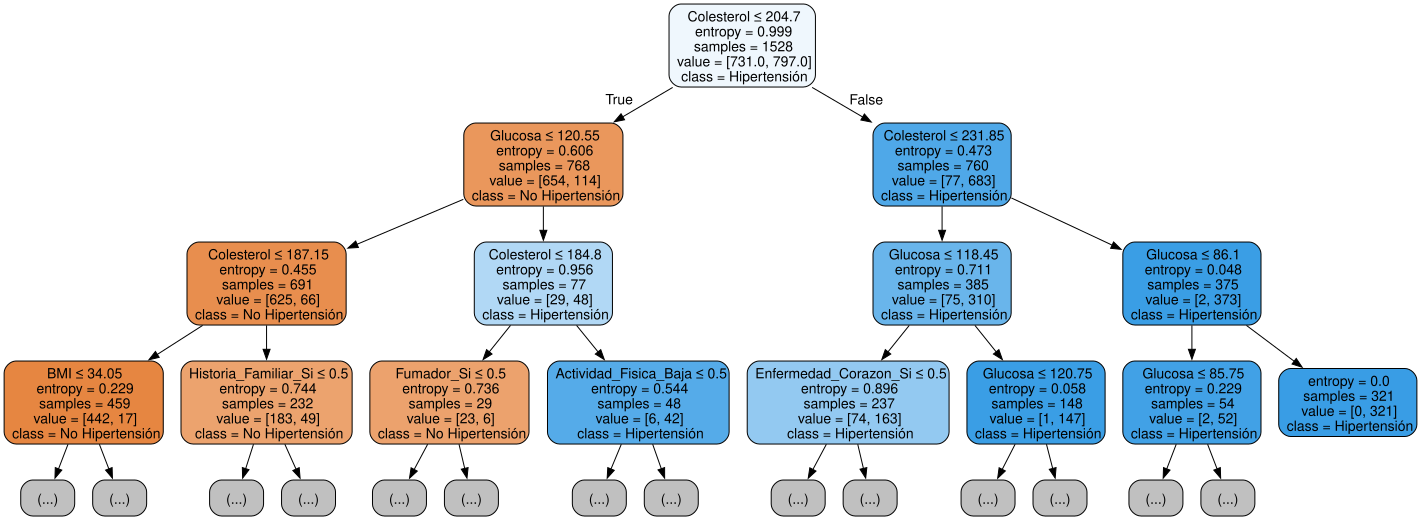

In [83]:
from sklearn.tree import export_graphviz
import graphviz

rf_model = mejor_pipeline.named_steps["model"]
feature_names = mejor_pipeline.named_steps["transformer"].get_feature_names_out()

# Exporto el árbol a formato DOT
dot_data = export_graphviz(
    rf_model,
    out_file=None,
    feature_names=feature_names,
    class_names=["No Hipertensión", "Hipertensión"],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3#
)

# Generó la visualización con graphviz
graph = graphviz.Source(dot_data)
graph.render("arbol_hipertension", format="png", cleanup=True)  # guarda el árbol como imagen
graph  # lo muestra en el notebook

* Regla 1: Si Colesterol <= 204.7, Glucosa <= 120.55 , Colesterol <= 187.15, entonces → el paciente sera  No Hipertenso.
* Regla 2: Si Colesterol <= 204.7, Glucosa > 120.55 , Colesterol > 184.8,entonces → el paciente sera Hipertenso.
* Regla 3: Si Colesterol >  204.7, Colesterol <= 231.85 , Glucosa <= 118.45, entonces → el paciente sera  Hipertenso.
* Regla 4: Si Colesterol >  204.7, Colesterol > 231.85 , Glucosa <= 86.1, entonces → el paciente sera  Hipertenso.

# E. Análisis de resultados.

## 1. -¿Qué puedes decir de los valores de las métricas recall y precisión para cada una de las clases en cada modelo? ¿Cuál de estás métricas consideras que es más importante con base en la descripción del problema?

las metricas `Recall` y `Precision` me permite lo siguiente:
* `Precisión` : de los que el modelo predice como enfermos, ¿cuántos realmente lo son?
* `Sensibilidad / Recall` : de todos los enfermos reales, ¿cuántos detecta el modelo?

Dado que se trata de un problema médico cuyo objetivo es estimar el riesgo de hipertensión en pacientes, la métrica más relevante es Recall (Sensibilidad).
Esto se debe a que, en este contexto, el error más grave sería clasificar a un paciente hipertenso como sano (falso negativo). Por lo tanto, el modelo debe minimizar al máximo este tipo de errores para garantizar que la mayoría de los pacientes en riesgo sean identificados correctamente.

En este sentido, el modelo que mejor se adapta a mi caso de estudio es el árbol de decisión, ya que alcanza un Recall de 88.94%, lo que indica que identifica correctamente a la gran mayoría de los pacientes con hipertensión, cometiendo un bajo porcentaje de errores al clasificar a pacientes hipertensos como sanos.

## 2. -¿Consideras que el rendimiento de los modelos es adecuado? Si no es así, ¿cómo podrían mejorarse los resultados?

Comparando las metricas de train y test, se observa que tanto el modelo de Arbol de decision como el de  KNN no presentan mayor variacion significativa entre ambos. Esto indica  que los modelos no sufren  de sobreajuste ni de bajoajuste, lo cual refleja un rendimiento adecuado. Además, las metricas  de Recall y precision muestran valores altos y balanceados,lo que confirma que ambos modelos lograun un desempeño estable y confiable en la clasificación de pacientes con riesgo de hipertensión

Podriamos mejorar los resultados con:

* `Recolección de más datos clínicos` para entrenar con mayor diversidad y robustez.
* `Ingeniería de características`, incorporando nuevas variables clínicas que puedan aportar más información al modelo.

Finalmente, para complementar este análisis se incluye la curva ROC, que permite evaluar el rendimiento global de los modelos considerando todos los posibles umbrales de clasificación, y comparar su capacidad discriminativa.

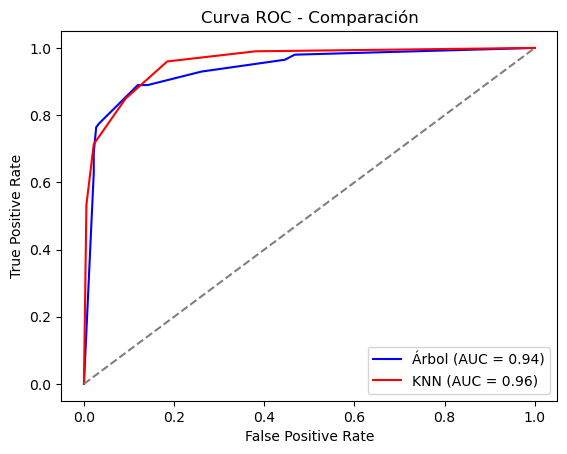

In [84]:
from sklearn.metrics import roc_curve, auc


y_probs = mejor_pipeline.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_enc, y_probs)
roc_auc = auc(fpr, tpr)

y_probs_knn = mejor_pipeline_k.predict_proba(x_test_K)[:,1]
fpr_knn, tpr_knn, _ = roc_curve(y_test_enc_K, y_probs_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure()
plt.plot(fpr, tpr, label=f"Árbol (AUC = {roc_auc:.2f})", color="blue")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_knn:.2f})", color="red")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Comparación")
plt.legend()
plt.show()


## 3. ¿Cuáles son las variables más significativas según el mejor modelo basado en árboles de decisión? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

para poder ver cuales son las variables mas significativas utilizo  el atributo feature_importances_ para obtener un arreglo con los pesos asignados a cada variable. Entre más grande sea el peso, más importante es la variable asociada:
Utilizando los nombres de las variables almacenados en x_train.columns, podemos ver más claramente qué peso corresponde a qué variable. Primero creo un DataFrame con los valores almacenados en la variable importancia y, posteriormente, lo ordeno:


In [85]:
rf_model = mejor_pipeline.named_steps["model"]
feature_names = mejor_pipeline.named_steps["transformer"].get_feature_names_out()
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
importances

Colesterol                   0.806605
Glucosa                      0.140143
Enfermedad_Corazon_Si        0.015825
BMI                          0.013791
Historia_Familiar_Si         0.012180
Actividad_Fisica_Baja        0.006834
Fumador_Si                   0.004621
Enfermedad_Corazon_No        0.000000
Fumador_No                   0.000000
Actividad_Fisica_Moderada    0.000000
Actividad_Fisica_Alta        0.000000
Edad                         0.000000
Historia_Familiar_No         0.000000
Nivel_Stres                  0.000000
Medicacion_Ninguna           0.000000
Medicacion_InhibidorACE      0.000000
Medicacion_Diuretico         0.000000
Medicacion_BloqueadorBeta    0.000000
Medicacion_Otro              0.000000
dtype: float64

El modelo de Árbol de Decisión, entrenado con el criterio de entropía, una profundidad máxima de 4 y un número mínimo de 4 datos por nodo, identificó como variables más relevantes a: `Colesterol`, `Glucosa`, `Enfermedad cardíaca`, `BMI`, `Antecedentes familiares`, `Nivel de actividad física` y `Consumo de tabaco`.

Interpretación de las variables seleccionadas:
Los resultados muestran que los pacientes con niveles elevados de colesterol y glucosa son los más propensos a desarrollar hipertensión. Además, este riesgo aumenta en aquellos que presentan enfermedad cardíaca, vida sedentaria, hábito de fumar y antecedentes familiares.

Este conocimiento es valioso en el contexto médico, ya que permite focalizar los esfuerzos de prevención y diagnóstico temprano en pacientes con estas características, ayudando a los profesionales de la salud a priorizar exámenes y recomendar intervenciones personalizadas en estilo de vida y tratamiento.

## 4. Si los dos modelos proporcionan resultados similares en cuanto a las métricas de rendimiento ¿Cuál seleccionarías tomando en cuenta el contexto del problema?

Aunque la curva ROC mostró que el modelo KNN es ligeramente superior en rendimiento (AUC = 0.96 frente a 0.94 del Árbol de Decisión),seleccionaría el modelo de Árbol de Decisión para este caso, ya que permite interpretar y explicar fácilmente los resultados mediante las reglas generadas y la visualización del árbol, Esto es especialmente importante en un contexto médico, donde la transparencia y la explicabilidad del modelo son fundamentales. Además, el árbol ofrece un buen desempeño en las métricas y no se ve tan afectado por la “maldición de la dimensionalidad” como el modelo KNN, lo que lo hace más adecuado para este caso de estudio.
